In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
model = joblib.load('fraud_model.pkl')

week1 = pd.read_csv('week1_baseline.csv')
week2 = pd.read_csv('week2_drift.csv')
week3 = pd.read_csv('week3_drift.csv')
week4 = pd.read_csv('week4_drift.csv')

print("Model and datasets loaded successfully!")

Model and datasets loaded successfully!


In [3]:
def evaluate_model(data, week_name):
    X = data.drop('Class', axis=1)
    y = data['Class']
    
    y_pred = model.predict(X)
    
    auc = roc_auc_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{week_name} Results:")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
    return auc, precision, recall, f1

print("Function created successfully!")

Function created successfully!


In [5]:
print("Model Performance Over Time:")
print("-" * 50)

auc1, pre1, rec1, f11 = evaluate_model(week1, "Week 1 - Baseline")
auc2, pre2, rec2, f12 = evaluate_model(week2, "Week 2 - Slight Drift")
auc3, pre3, rec3, f13 = evaluate_model(week3, "Week 3 - Moderate Drift")
auc4, pre4, rec4, f14 = evaluate_model(week4, "Week 4 - Severe Drift")

Model Performance Over Time:
--------------------------------------------------

Week 1 - Baseline Results:
AUC-ROC:   0.9915
Precision: 0.9667
Recall:    0.9831
F1 Score:  0.9748

Week 2 - Slight Drift Results:
AUC-ROC:   0.9674
Precision: 0.9663
Recall:    0.9348
F1 Score:  0.9503

Week 3 - Moderate Drift Results:
AUC-ROC:   0.9883
Precision: 0.9692
Recall:    0.9767
F1 Score:  0.9730

Week 4 - Severe Drift Results:
AUC-ROC:   0.9255
Precision: 0.9877
Recall:    0.8511
F1 Score:  0.9143


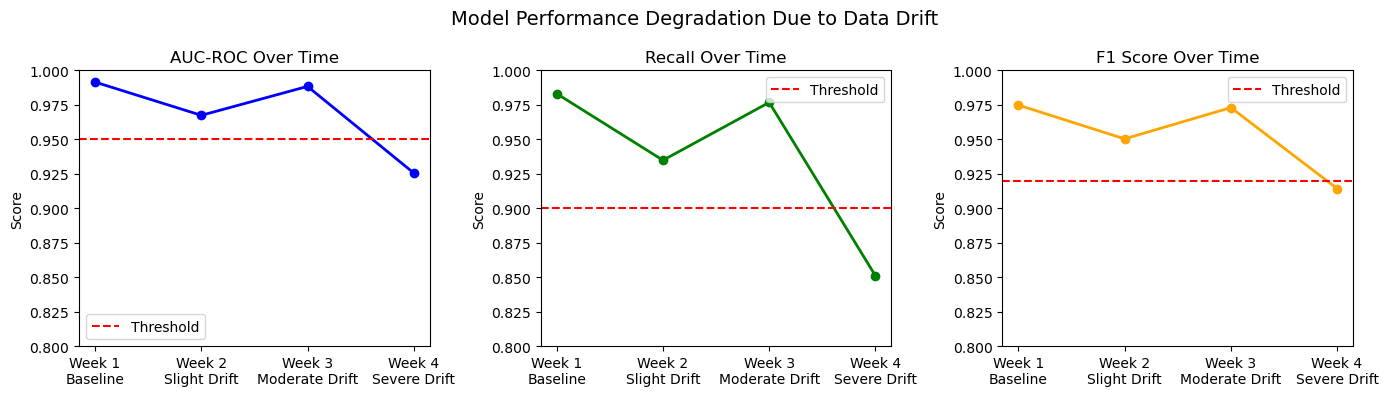

In [6]:
weeks = ['Week 1\nBaseline', 'Week 2\nSlight Drift', 'Week 3\nModerate Drift', 'Week 4\nSevere Drift']

auc_scores = [auc1, auc2, auc3, auc4]
recall_scores = [rec1, rec2, rec3, rec4]
f1_scores = [f11, f12, f13, f14]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(weeks, auc_scores, marker='o', color='blue', linewidth=2)
axes[0].set_title('AUC-ROC Over Time')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0.8, 1.0])
axes[0].axhline(y=0.95, color='red', linestyle='--', label='Threshold')
axes[0].legend()

axes[1].plot(weeks, recall_scores, marker='o', color='green', linewidth=2)
axes[1].set_title('Recall Over Time')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0.8, 1.0])
axes[1].axhline(y=0.90, color='red', linestyle='--', label='Threshold')
axes[1].legend()

axes[2].plot(weeks, f1_scores, marker='o', color='orange', linewidth=2)
axes[2].set_title('F1 Score Over Time')
axes[2].set_ylabel('Score')
axes[2].set_ylim([0.8, 1.0])
axes[2].axhline(y=0.92, color='red', linestyle='--', label='Threshold')
axes[2].legend()

plt.suptitle('Model Performance Degradation Due to Data Drift', fontsize=14)
plt.tight_layout()
plt.show()